BV号       0
AV号       0
CID       0
UP主ID     0
UP主名称     0
UP主粉丝数    0
作品总数      0
视频标题      0
视频分类标签    0
视频时长      0
发布日期      0
发布时间      0
视频简介      3
播放量       0
点赞数       0
投币数       0
收藏数       0
分享数       0
评论数       0
弹幕数       0
传播效果指数    0
dtype: int64
8
                AV号           CID         UP主ID        UP主粉丝数        作品总数  \
count  4.100000e+01  4.100000e+01  4.100000e+01  4.100000e+01   41.000000   
mean   7.535141e+08  9.847794e+08  9.550957e+07  1.496302e+06  134.219512   
std    3.479420e+08  4.421769e+08  7.234439e+06  1.797652e+05    7.808688   
min    2.537444e+08  2.217898e+08  5.031638e+07  1.468227e+06  133.000000   
25%    4.881377e+08  5.584623e+08  9.663940e+07  1.468227e+06  133.000000   
50%    7.217286e+08  1.014917e+09  9.663940e+07  1.468227e+06  133.000000   
75%    9.233759e+08  1.397512e+09  9.663940e+07  1.468227e+06  133.000000   
max    1.851435e+09  1.659411e+09  9.663940e+07  2.619286e+06  183.000000   

              视频时长           播放量       

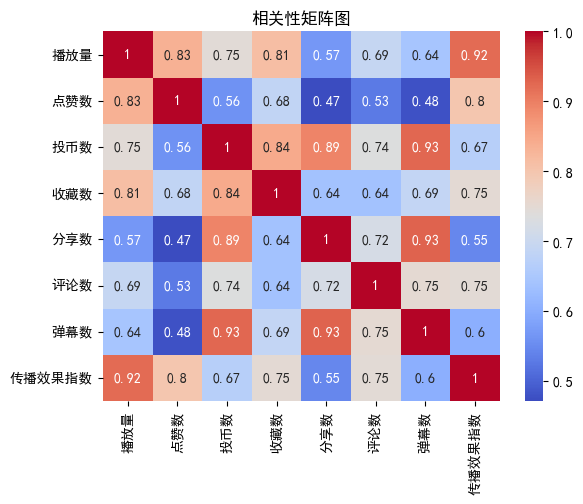

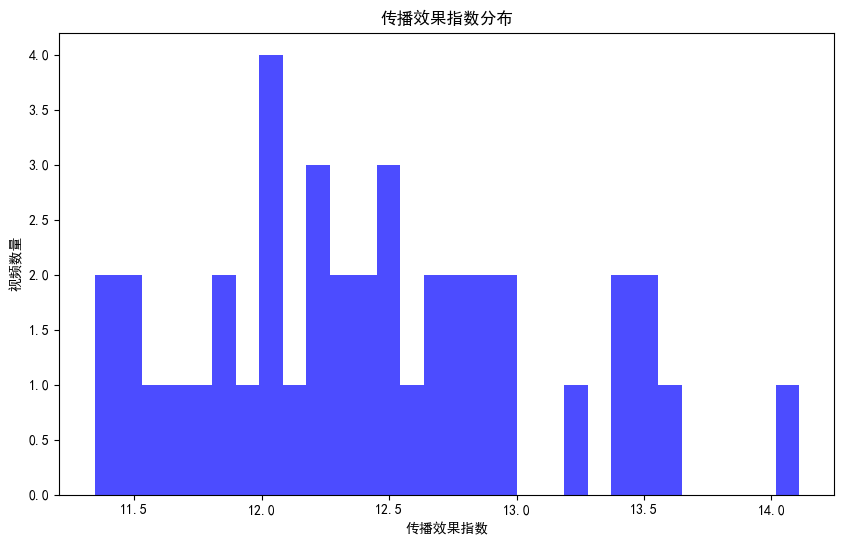

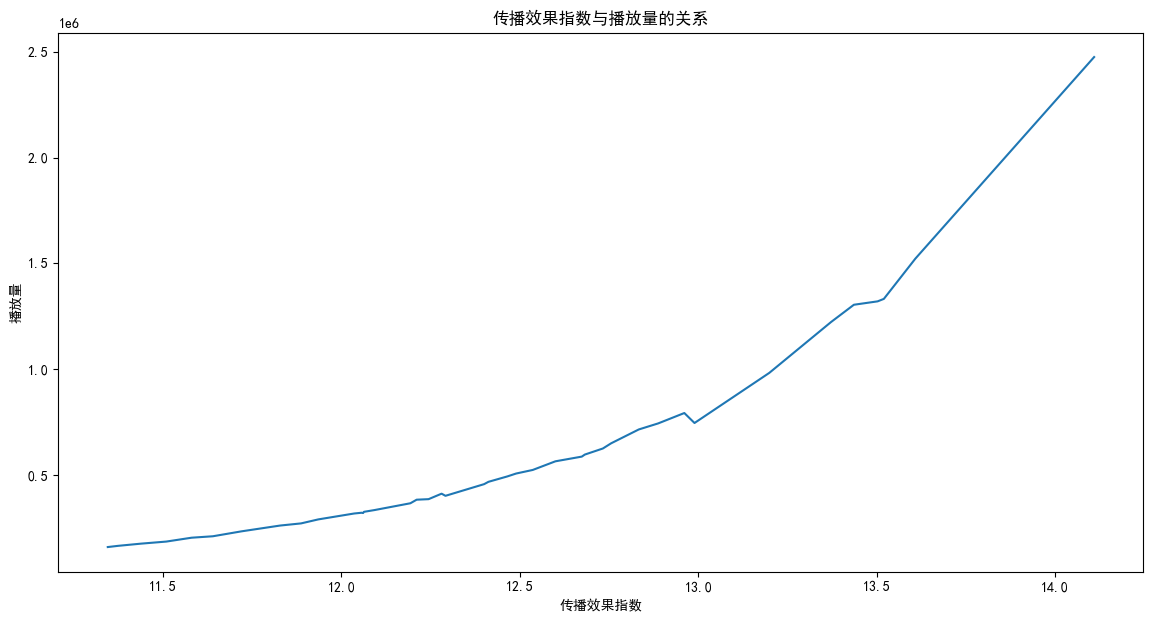

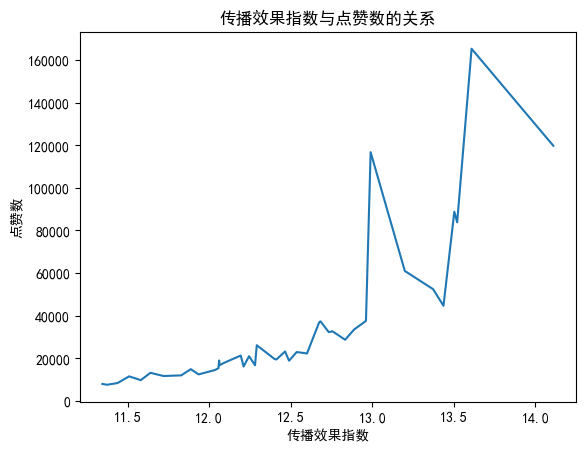

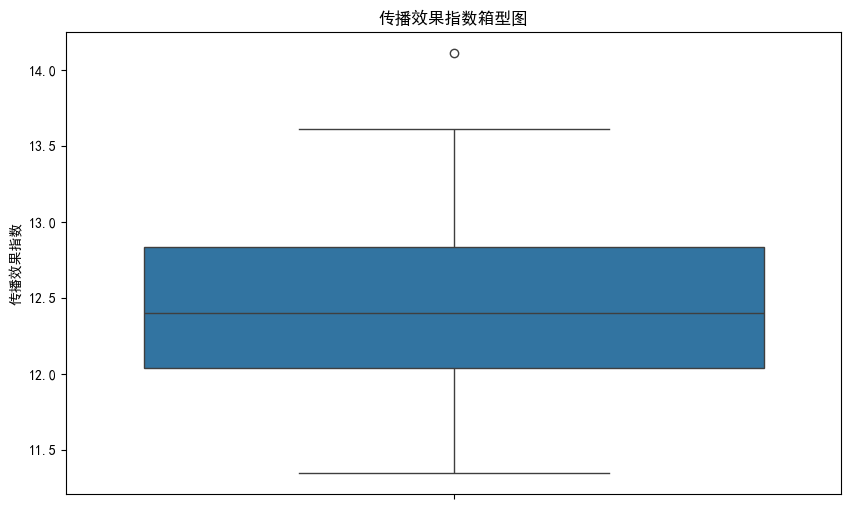

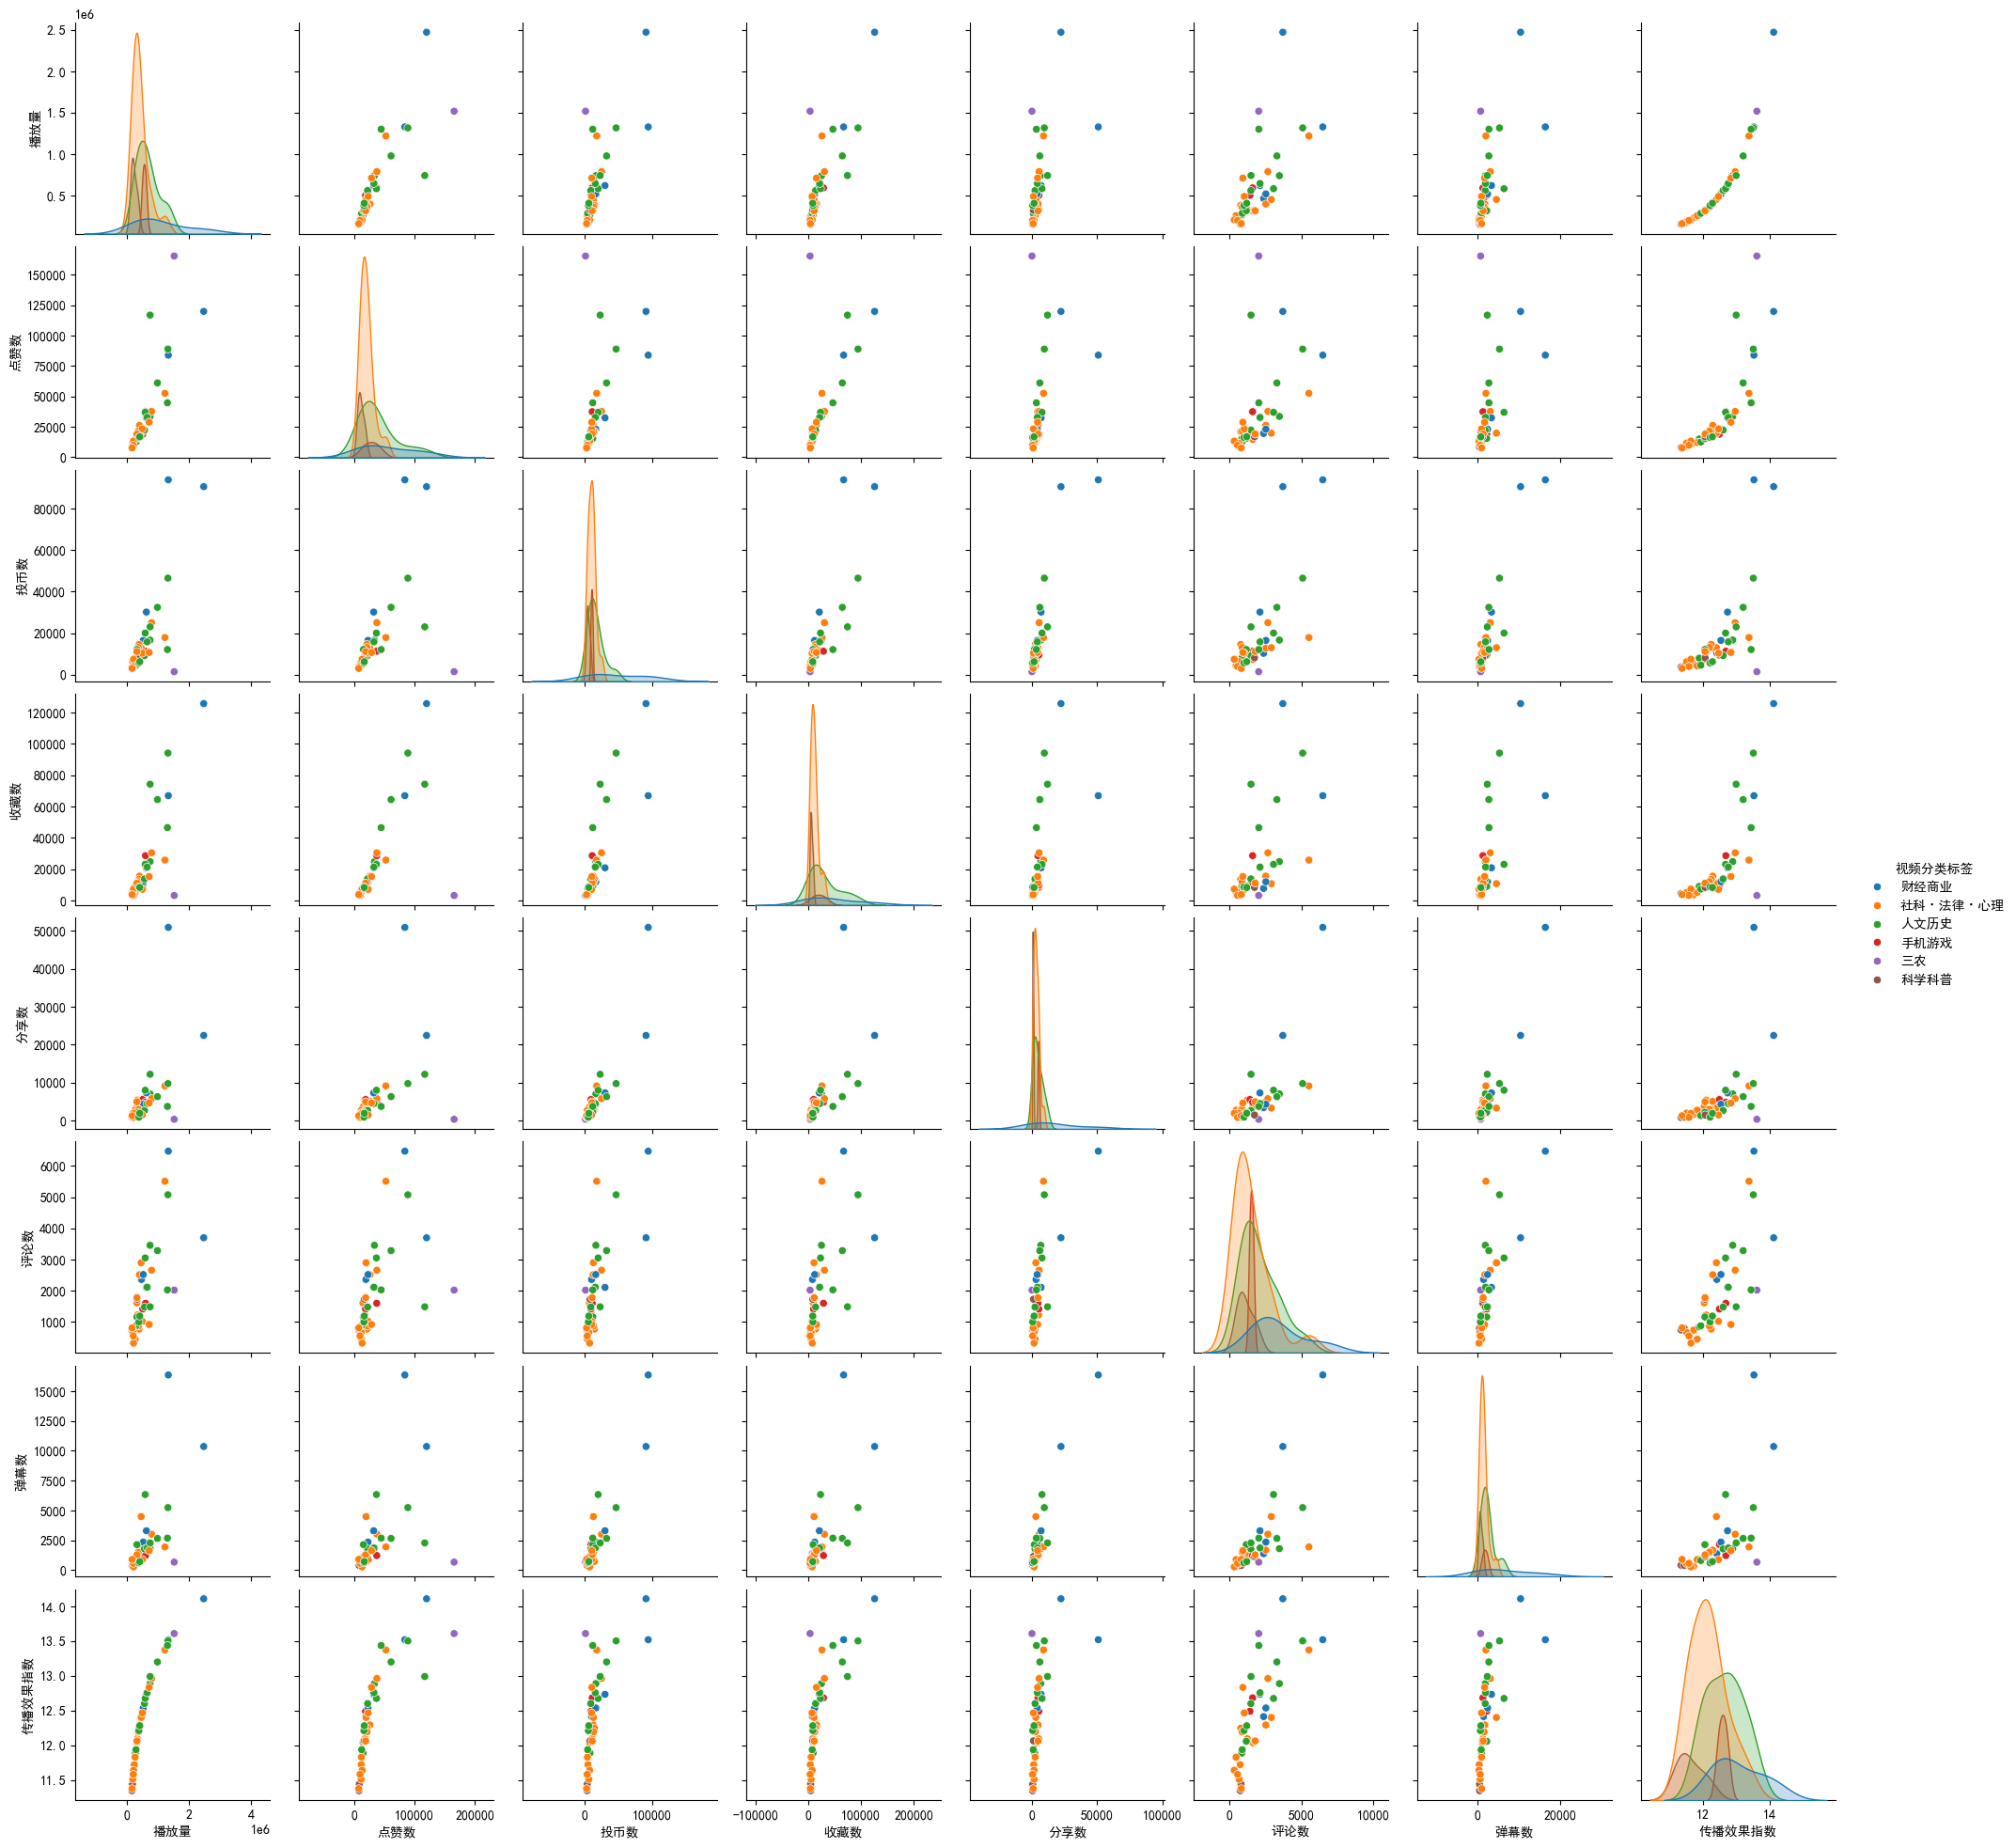

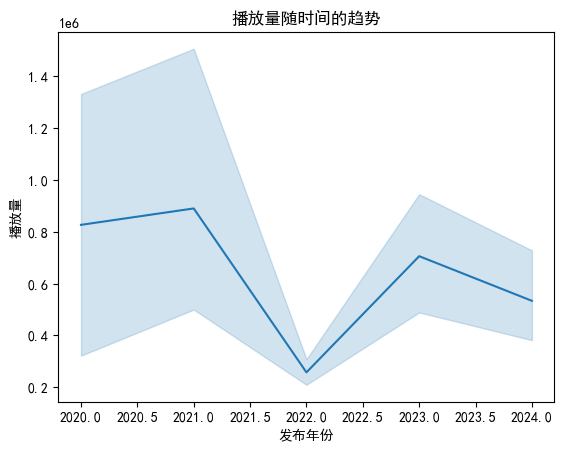

视频分类标签
社科·法律·心理    17
人文历史        13
财经商业         5
科学科普         3
手机游戏         2
三农           1
Name: count, dtype: int64


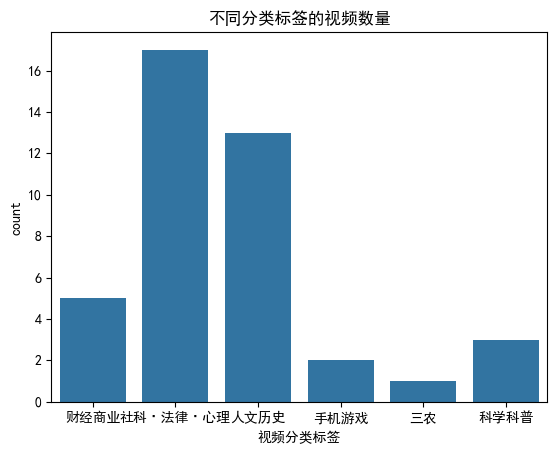

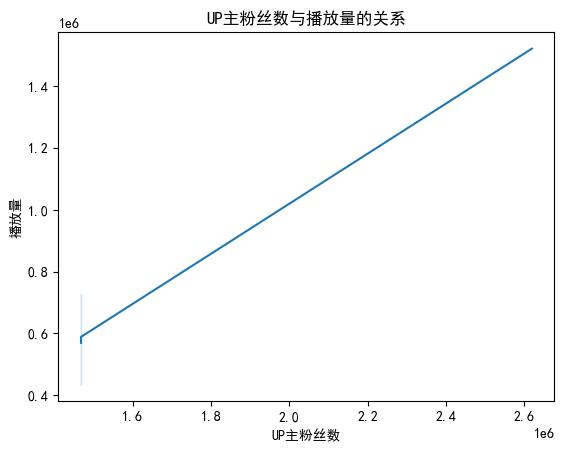

斜率: 0.11702002548851827, 截距: -141170.92246534268, R-squared: 0.3755264737693653
Topic 0:
硬核社会学 心理疾病的社会学本质是什么 马克思会如何看待巴以问题 资本主义的本质是什么 35岁即失业 动物打工人为何爆火 前后三十年 控制世界的新宗教 你为什么老想摆烂 当代工作危机的本质是什么
Topic 1:
硬核经济学 金融国战到底是怎么打的 世界经济金融化的三十年 民众没钱能有多可怕 详解世界大战的真正起因 以美国为例 现在就业难 失业快的本质原因 东亚经济红利期 盛宴已过
Topic 2:
会议记录 读懂马克思 马克思主义与白左和西方经济学的本质区别 如何入门资本论 经济学和工业党为什么都是错误的 游戏社会学 法律为何总要制造罪人 审判是为了正义还是统治 我们如何重返未来 官僚和资本的双重压力下
Topic 3:
硬核国关学 奇葩小国为什么无法崛起 但它不必是 国际世界当然是黑暗森林 游戏社会学 审判是为了正义还是统治 法律为何总要制造罪人 我们如何重返未来 官僚和资本的双重压力下 影视社会学
Topic 4:
精英社会学 精英是如何统治社会的 权力 的本质是什么 游戏社会学 审判是为了正义还是统治 法律为何总要制造罪人 我们如何重返未来 官僚和资本的双重压力下 影视社会学


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# 读取CSV文件
df = pd.read_csv('video.csv')

# 数据清洗
# 检查缺失值
print(df.isnull().sum())
# 删除缺失值
df = df.dropna()

# 检查重复值
print(df.duplicated().sum())
# 删除重复值
df = df.drop_duplicates()

# 描述性统计分析
print(df.describe())

# 相关性分析
correlation_matrix = df[['播放量', '点赞数', '投币数', '收藏数', '分享数', '评论数', '弹幕数', '传播效果指数']].corr()
print("相关性矩阵：\n", correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('相关性矩阵图')
plt.show()

# 传播效果指数分析
plt.figure(figsize=(10, 6))
plt.hist(df['传播效果指数'], bins=30, alpha=0.7, color='blue')
plt.xlabel('传播效果指数')
plt.ylabel('视频数量')
plt.title('传播效果指数分布')
plt.show()

# 传播效果指数与互动指标的关系
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='传播效果指数', y='播放量')
plt.title('传播效果指数与播放量的关系')
plt.show()

sns.lineplot(data=df, x='传播效果指数', y='点赞数')
plt.title('传播效果指数与点赞数的关系')
plt.show()

# 传播效果指数箱型图
plt.figure(figsize=(10, 6))
sns.boxplot(data=df['传播效果指数'])
plt.title('传播效果指数箱型图')
plt.show()

# 散点图矩阵
sns.pairplot(data=df, vars=['播放量', '点赞数', '投币数', '收藏数', '分享数', '评论数', '弹幕数', '传播效果指数'], hue='视频分类标签')
plt.show()

# 趋势分析
df['发布日期'] = pd.to_datetime(df['发布日期'])
df['发布年份'] = df['发布日期'].dt.year
sns.lineplot(data=df, x='发布年份', y='播放量')
plt.title('播放量随时间的趋势')
plt.show()

# 分类分析
category_counts = df['视频分类标签'].value_counts()
print(category_counts)
sns.countplot(data=df, x='视频分类标签')
plt.title('不同分类标签的视频数量')
plt.show()

# 用户行为分析
sns.lineplot(data=df, x='UP主粉丝数', y='播放量')
plt.title('UP主粉丝数与播放量的关系')
plt.show()

# 预测模型
# 以播放量为基准，构建点赞数的预测模型
X = df[['UP主粉丝数', '视频时长']]
y = df['点赞数']
slope, intercept, r_value, p_value, std_err = linregress(X['UP主粉丝数'], y)
print(f'斜率: {slope}, 截距: {intercept}, R-squared: {r_value**2}')

# 文本分析
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

vectorizer = TfidfVectorizer(stop_words='english')
tfidf = vectorizer.fit_transform(df['视频标题'])
nmf = NMF(n_components=5, random_state=42)
nmf.fit(tfidf)
feature_names = vectorizer.get_feature_names_out()

# 显示每个主题的前10个词
for topic_idx, topic in enumerate(nmf.components_):
    print(f"Topic {topic_idx}:")
    print(" ".join([feature_names[i] for i in topic.argsort()[:-11:-1]]))